Predictive modelling and regression analysis

We use the cleaned data from Task 1: 1,337 rows, with only one exact duplicate removed. Extreme values are retained.

**Linear regression:** use age, BMI and smoking status to predict medical charges.

**Logistic regression:** use actual recorded charges, age and BMI to predict smoking status. This is a separate model: it does not use the linear model's predictions.

Both models use an 80% training / 20% test split. The test rows are reserved for evaluation. This is a classroom analysis; results do not establish causation or performance for all US residents. Recorded charges must be available to use the logistic model.

Source: [Medical Cost Personal Dataset on Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance).

Imports and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("insurance_cleaned.csv")

linear_data = df[["age", "bmi", "smoker", "charges"]].copy()

linear_data["smoker"] = linear_data["smoker"].map({"no": 0, "yes": 1})

linear_data.head()

,age,bmi,smoker,charges
0,19,27.900,1,16884.92400
1,18,33.770,0,1725.55230
2,28,33.000,0,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


Linear regression: training and test data

The random seed keeps the split repeatable. We keep values in original units so the equation is easy to interpret.

In [3]:
train_data, test_data = train_test_split(
    linear_data,
    test_size=0.20,
    random_state=42
)

Correlations in the training data

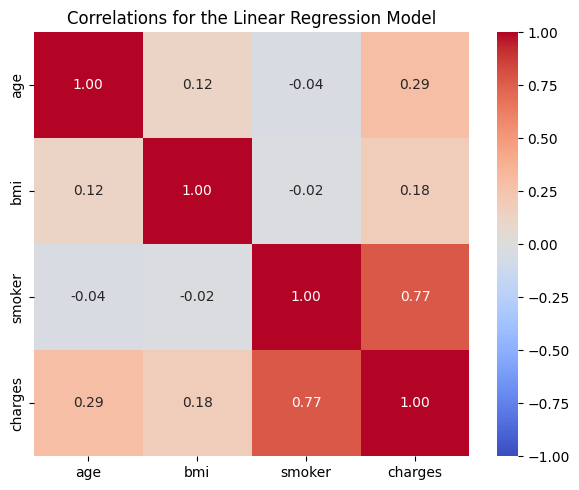

In [4]:
correlations = train_data.corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlations for the Linear Regression Model")
plt.tight_layout()
plt.show()

Select inputs and the target

In [5]:
X_train = train_data[["age", "bmi", "smoker"]]
y_train = train_data["charges"]

X_test = test_data[["age", "bmi", "smoker"]]
y_test = test_data["charges"]

Fit the linear model

OLS estimates the intercept and slopes together by minimizing squared errors in the training data.

In [6]:
import statsmodels.api as sm

X_train_constant = sm.add_constant(X_train)

linear_model = sm.OLS(y_train, X_train_constant).fit()

Estimated coefficients

Each slope describes the predicted dollar change for one extra input unit, holding the other inputs fixed. Smoking is 0 = no and 1 = yes.

In [7]:
coefficients = linear_model.params

coefficients

const    -10770.887828
age         251.876177
bmi         304.802557
smoker    23074.261735
dtype: float64

The fitted regression equation

In [8]:
print(
    f"Predicted charges = {coefficients['const']:.2f}"
    f" {coefficients['age']:+.2f} × age"
    f" {coefficients['bmi']:+.2f} × BMI"
    f" {coefficients['smoker']:+.2f} × smoker"
)

Predicted charges = -10770.89 +251.88 × age +304.80 × BMI +23074.26 × smoker


Significance tests for the coefficients

For each coefficient, H₀: coefficient = 0; H₁: coefficient ≠ 0. We use α = 0.05. Classical OLS t-tests assume a suitable linear model, independent errors and constant error variance.

In [9]:
alpha = 0.05

coefficient_tests = pd.DataFrame({
    "Coefficient": linear_model.params,
    "t-statistic": linear_model.tvalues,
    "p-value": linear_model.pvalues
})

coefficient_tests

,Coefficient,t-statistic,p-value
const,-10770.887828,-10.180721,2.706489e-23
age,251.876177,18.631299,2.804063e-67
bmi,304.802557,9.752576,1.393682e-21
smoker,23074.261735,49.169954,2.894952e-276


In [10]:
for feature in ["age", "bmi", "smoker"]:
    p_value = linear_model.pvalues[feature]

    if p_value <= alpha:
        print(f"{feature}: Reject H0 — the coefficient is significantly different from zero.")
    else:
        print(f"{feature}: Do not reject H0 — not enough evidence that the coefficient differs from zero.")

age: Reject H0 — the coefficient is significantly different from zero.
bmi: Reject H0 — the coefficient is significantly different from zero.
smoker: Reject H0 — the coefficient is significantly different from zero.


Significance test for the overall model

H₀: all three slopes are zero. H₁: at least one slope differs from zero. Significance is not the same as accurate predictions.

In [11]:
print(f"F-statistic: {linear_model.fvalue:.3f}")
print(f"p-value: {linear_model.f_pvalue:.6g}")

if linear_model.f_pvalue <= alpha:
    print("Reject H0 — the inputs together provide evidence of a relationship with charges.")
else:
    print("Do not reject H0 — not enough evidence that the inputs improve on an intercept-only model.")

F-statistic: 941.627
p-value: 5.87665e-299
Reject H0 — the inputs together provide evidence of a relationship with charges.


Predict charges for the test data

Add the same intercept column used during training, then predict charges for the unseen test rows.

In [12]:
X_test_constant = sm.add_constant(X_test, has_constant="add")
y_pred = linear_model.predict(X_test_constant)

Linear regression performance

MAE is the average absolute error in dollars. MSE averages squared errors; RMSE returns that measure to dollars. MAPE expresses errors as a percentage and can be large for low actual charges. Lower is better for these four errors.

R² measures performance relative to predicting the test-set mean: 1 is perfect, 0 matches that reference, and negative is worse. The separate baseline below uses the training mean, which would actually be available before seeing test outcomes.

In [13]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r_squared = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"MSE: {mse:,.2f} dollars squared")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R-squared: {r_squared:.3f}")

baseline_pred = [y_train.mean()] * len(y_test)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
print(f"Baseline RMSE (always predict the training mean): ${baseline_rmse:,.2f}")
print("Model beats this baseline on RMSE:", rmse < baseline_rmse)
print("Negative charge predictions:", (y_pred < 0).sum())

MAE: $4,191.70
MSE: 35,841,574.82 dollars squared
RMSE: $5,986.78
MAPE: 43.72%
R-squared: 0.805
Baseline RMSE (always predict the training mean): $13,612.43
Model beats this baseline on RMSE: True
Negative charge predictions: 2


Actual and predicted charges

Error = actual minus predicted. A positive error is an underprediction; a negative error is an overprediction. We keep negative predictions in the evaluation rather than silently changing them.

In [14]:
comparison = pd.DataFrame({
    "Actual charges": y_test,
    "Predicted charges": y_pred
})
comparison["Error"] = comparison["Actual charges"] - comparison["Predicted charges"]
comparison.head(10).round(2)

,Actual charges,Predicted charges,Error
899,8688.86,8433.67,255.18
1063,5708.87,4336.47,1372.40
1255,11436.74,13165.04,-1728.30
298,38746.36,30593.70,8152.66
237,4463.21,8738.64,-4275.44
481,9304.70,13004.19,-3699.49
240,38511.63,29273.64,9237.99
277,2150.47,2177.09,-26.62
415,7345.73,10922.95,-3577.22
706,10264.44,10315.83,-51.39


Visual checks

Predictions close to the diagonal are more accurate. The training residual plot checks for patterns or changing error spread; a straight-line model may miss differences between smokers and non-smokers.

The residual plot shows clear bands and changing spread rather than an even random scatter around zero. The basic linear model misses some structure, even though its test performance improves on the mean-only baseline. The robust significance check below addresses unequal error spread, but does not remove this model limitation.

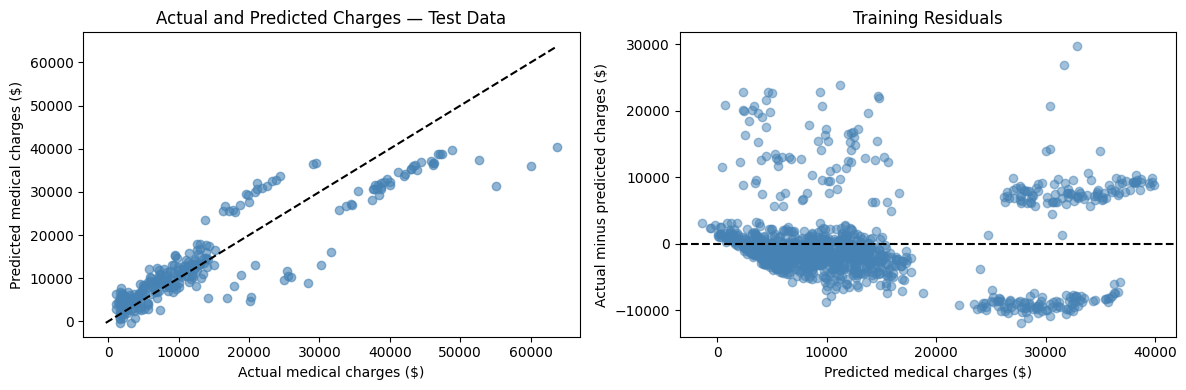

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue")
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "k--")
axes[0].set_title("Actual and Predicted Charges — Test Data")
axes[0].set_xlabel("Actual medical charges ($)")
axes[0].set_ylabel("Predicted medical charges ($)")

axes[1].scatter(linear_model.fittedvalues, linear_model.resid, alpha=0.5, color="steelblue")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Training Residuals")
axes[1].set_xlabel("Predicted medical charges ($)")
axes[1].set_ylabel("Actual minus predicted charges ($)")

plt.tight_layout()
plt.show()

Significance check allowing unequal error spread

Medical charge errors may have unequal spread. HC3 robust standard errors provide a sensitivity check for our coefficient t-tests and overall F-test. This keeps the same coefficients and predictions; it does not repair a poorly fitting equation or establish causation.

In [16]:
robust_model = linear_model.get_robustcov_results(cov_type="HC3", use_t=True)

robust_tests = pd.DataFrame({
    "Coefficient": robust_model.params,
    "Robust t-statistic": robust_model.tvalues,
    "Robust p-value": robust_model.pvalues
}, index=linear_model.params.index)

print(robust_tests.to_string())
print(f"Robust overall F-statistic: {robust_model.fvalue:.3f}")
print(f"Robust overall p-value: {robust_model.f_pvalue:.6g}")

for feature in ["age", "bmi", "smoker"]:
    if robust_tests.loc[feature, "Robust p-value"] <= alpha:
        print(f"{feature}: Reject H0 using the robust check.")
    else:
        print(f"{feature}: Do not reject H0 using the robust check.")

         Coefficient  Robust t-statistic  Robust p-value
const  -10770.887828           -9.859355    5.282497e-22
age       251.876177           18.329699    1.931774e-65
bmi       304.802557            9.068836    5.653512e-19
smoker  23074.261735           35.713172   2.712110e-184
Robust overall F-statistic: 564.928
Robust overall p-value: 1.28214e-219
age: Reject H0 using the robust check.
bmi: Reject H0 using the robust check.
smoker: Reject H0 using the robust check.


Predict charges for new examples

These are hypothetical people, not additional observations. Predictions estimate charges; they are not exact bills.

In [17]:
new_people = pd.DataFrame({
    "age": [30, 40, 40],
    "bmi": [25.0, 30.0, 30.0],
    "smoker": [0, 0, 1]
})

new_inputs = sm.add_constant(new_people, has_constant="add")
new_people["Predicted charges"] = linear_model.predict(new_inputs)
new_people.round(2)

,age,bmi,smoker,Predicted charges
0,30,25.0,0,4405.46
1,40,30.0,0,8448.24
2,40,30.0,1,31522.50


Binary logistic regression: predict smoking status

Inputs: actual recorded charges, age and BMI. Target: smoker (0 = no, 1 = yes). We split again with stratification, which keeps similar smoker proportions in training and test data.

The model predicts the probability of "yes". We choose a threshold of 0.5 before evaluating it: probability ≥ 0.5 means "yes"; otherwise "no". We use original units; no whole-dataset scaling is used.

In [18]:
logistic_X = df[["charges", "age", "bmi"]].copy()
logistic_y = df["smoker"].map({"no": 0, "yes": 1})

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    logistic_X, logistic_y,
    test_size=0.20, random_state=42, stratify=logistic_y
)

print("Training rows:", len(X_train_log))
print("Test rows:", len(X_test_log))
print("Test smokers:", y_test_log.sum())
print("Test non-smokers:", (y_test_log == 0).sum())

Training rows: 1069
Test rows: 268
Test smokers: 55
Test non-smokers: 213


Fit the logistic model and show its coefficients

Logistic regression fits coefficients that make the observed yes/no outcomes likely. A coefficient acts on log-odds, not directly on probability. A positive coefficient raises estimated smoking probability when the other inputs are held fixed; a negative one lowers it.

In [19]:
X_train_log_constant = sm.add_constant(X_train_log, has_constant="add")
X_test_log_constant = sm.add_constant(X_test_log, has_constant="add")

logistic_model = sm.Logit(y_train_log, X_train_log_constant).fit(disp=False)
logistic_coefficients = logistic_model.params

print("Model converged:", logistic_model.mle_retvals["converged"])
logistic_coefficients.to_frame("Estimated coefficient").round(6)

Model converged: True


,Estimated coefficient
const,4.911779
charges,0.000354
age,-0.092770
bmi,-0.323524


The logistic regression equation

First calculate z from the inputs. Then convert z into a probability using p = 1 / (1 + exp(−z)). The value exp(−z) means e raised to the power −z. The printed equation is rounded for reading; predictions use the full-precision coefficients.

In [20]:
print(
    f"z = {logistic_coefficients['const']:.6f}"
    f" {logistic_coefficients['charges']:+.6f} × charges"
    f" {logistic_coefficients['age']:+.6f} × age"
    f" {logistic_coefficients['bmi']:+.6f} × BMI"
)
print("P(smoker = yes) = 1 / (1 + exp(-z))")
print("Predict yes if probability >= 0.5; otherwise predict no.")

z = 4.911779 +0.000354 × charges -0.092770 × age -0.323524 × BMI
P(smoker = yes) = 1 / (1 + exp(-z))
Predict yes if probability >= 0.5; otherwise predict no.


Predict probabilities and yes/no outcomes for the test data

In [21]:
smoker_probability = logistic_model.predict(X_test_log_constant)
smoker_prediction = (smoker_probability >= 0.5).astype(int)

logistic_comparison = pd.DataFrame({
    "Actual smoker": y_test_log.map({0: "No", 1: "Yes"}),
    "Probability of yes": smoker_probability,
    "Predicted smoker": smoker_prediction.map({0: "No", 1: "Yes"})
})
logistic_comparison.head(10).round(3)

,Actual smoker,Probability of yes,Predicted smoker
575,No,0.007,No
931,No,0.016,No
955,Yes,0.992,Yes
144,Yes,0.549,Yes
683,No,0.080,No
632,No,0.027,No
613,No,0.001,No
1100,No,0.005,No
701,No,0.000,No
968,No,0.001,No


Confusion matrix

Rows are actual outcomes; columns are predictions. Correct predictions are on the diagonal. A false positive is a non-smoker predicted as a smoker; a false negative is a smoker predicted as a non-smoker.

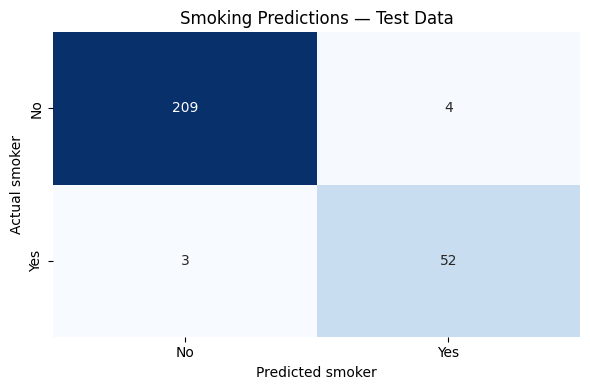

Correct non-smoker predictions: 209
Non-smokers incorrectly predicted as smokers: 4
Smokers incorrectly predicted as non-smokers: 3
Correct smoker predictions: 52


In [22]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

matrix = confusion_matrix(y_test_log, smoker_prediction, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(
    matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"]
)
plt.title("Smoking Predictions — Test Data")
plt.xlabel("Predicted smoker")
plt.ylabel("Actual smoker")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = matrix.ravel()
print("Correct non-smoker predictions:", tn)
print("Non-smokers incorrectly predicted as smokers:", fp)
print("Smokers incorrectly predicted as non-smokers:", fn)
print("Correct smoker predictions:", tp)

Classification metrics

Accuracy: fraction of all predictions that are correct. Precision: among predicted smokers, the fraction who are smokers. Recall: fraction of actual smokers identified. F1 combines precision and recall. ROC-AUC measures how well probabilities rank smokers above non-smokers across thresholds; 0.5 indicates chance-level ranking and 1 is perfect.

We calculate ROC-AUC from probabilities, not yes/no predictions. An always-non-smoker baseline helps us judge accuracy because most records are non-smokers.

In [23]:
accuracy = accuracy_score(y_test_log, smoker_prediction)
precision = precision_score(y_test_log, smoker_prediction, zero_division=0)
recall = recall_score(y_test_log, smoker_prediction, zero_division=0)
f1 = f1_score(y_test_log, smoker_prediction, zero_division=0)
roc_auc = roc_auc_score(y_test_log, smoker_probability)

print(f"Accuracy: {accuracy:.3f} ({accuracy:.1%})")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Always predict non-smoker accuracy: {(y_test_log == 0).mean():.3f}")

Accuracy: 0.974 (97.4%)
Precision: 0.929
Recall: 0.945
F1-score: 0.937
ROC-AUC: 0.996
Always predict non-smoker accuracy: 0.795


ROC curve

The curve shows the trade-off between identifying smokers and incorrectly flagging non-smokers as the threshold changes. The dashed diagonal represents chance-level ranking.

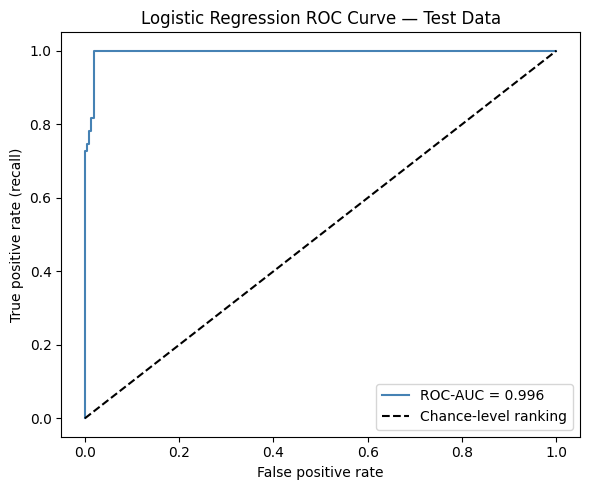

In [24]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test_log, smoker_probability
)

plt.figure(figsize=(6, 5))
plt.plot(false_positive_rate, true_positive_rate, color="steelblue", label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Chance-level ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("Logistic Regression ROC Curve — Test Data")
plt.legend()
plt.tight_layout()
plt.show()

Predict smoking probabilities for new examples

These hypothetical records contain already-known medical charges. We do not use predicted charges from the linear model. A model probability is an estimate, not confirmation of someone's smoking status.

In [25]:
new_smoking_examples = pd.DataFrame({
    "charges": [5000.0, 20000.0, 40000.0],
    "age": [40, 40, 40],
    "bmi": [30.0, 30.0, 30.0]
})

new_log_inputs = sm.add_constant(new_smoking_examples, has_constant="add")
new_probabilities = logistic_model.predict(new_log_inputs)

new_smoking_examples["Probability of yes"] = new_probabilities
new_smoking_examples["Predicted smoker"] = (new_probabilities >= 0.5).map({False: "No", True: "Yes"})
new_smoking_examples.round(3)

,charges,age,bmi,Probability of yes,Predicted smoker
0,5000.0,40,30.0,0.001,No
1,20000.0,40,30.0,0.195,No
2,40000.0,40,30.0,0.997,Yes


Results in plain language

The summaries below use the held-out test results. They describe this particular split and dataset; they are not promises of performance on new populations.

In [26]:
print(f"Linear regression: predictions differ from actual charges by ${mae:,.0f} on average in absolute terms.")
print(f"Test RMSE is ${rmse:,.0f} and test R-squared is {r_squared:.3f}.")
print(f"There are {(y_pred < 0).sum()} negative charge predictions, which are not realistic medical bills.")
print("The residual plot should be considered alongside the significance tests: this simple equation can miss patterns.")
print()
print(f"Logistic regression: {accuracy:.1%} of test records were classified correctly.")
print(f"It identified {recall:.1%} of test smokers, with precision {precision:.1%} and ROC-AUC {roc_auc:.3f}.")
print("These are associations, not evidence that changing an input causes the predicted outcome.")

Linear regression: predictions differ from actual charges by $4,192 on average in absolute terms.
Test RMSE is $5,987 and test R-squared is 0.805.
There are 2 negative charge predictions, which are not realistic medical bills.
The residual plot should be considered alongside the significance tests: this simple equation can miss patterns.

Logistic regression: 97.4% of test records were classified correctly.
It identified 94.5% of test smokers, with precision 92.9% and ROC-AUC 0.996.
These are associations, not evidence that changing an input causes the predicted outcome.
